In [7]:
import pandas as pd
import numpy as np

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
nigeria["Country"] = "Nigeria"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"

df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [8]:
df["Month"] = df["Month"].astype(int)

monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()
monthly_temp.head()

,Country,Month,T2M
0,Ethiopia,1,15.012608
1,Ethiopia,2,16.916313
2,Ethiopia,3,17.863333
3,Ethiopia,4,17.936485
4,Ethiopia,5,17.911144


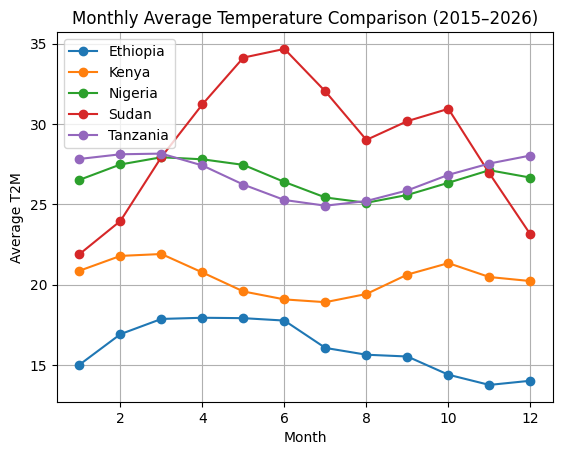

In [10]:
import matplotlib.pyplot as plt

plt.figure()

for country in monthly_temp["Country"].unique():
    data = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(data["Month"], data["T2M"], marker="o", label=country)

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Average T2M")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
temp_summary = df.groupby("Country")["T2M"].agg([
    "mean",
    "median",
    "std"
]).reset_index()

temp_summary

,Country,mean,median,std
0,Ethiopia,16.068500,16.04,1.898050
1,Kenya,20.427600,20.36,1.440824
2,Nigeria,26.656928,26.82,1.123335
3,Sudan,28.759007,29.16,4.681305
4,Tanzania,26.802422,26.99,1.325388


In [12]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg([
    "mean",
    "median",
    "std"
]).reset_index()

precip_summary

,Country,mean,median,std
0,Ethiopia,3.633795,0.82,6.289061
1,Kenya,1.468162,0.38,3.180228
2,Nigeria,4.213914,1.84,7.266742
3,Sudan,0.643875,0.00,3.057672
4,Tanzania,3.740256,0.64,8.003947


<Figure size 640x480 with 0 Axes>

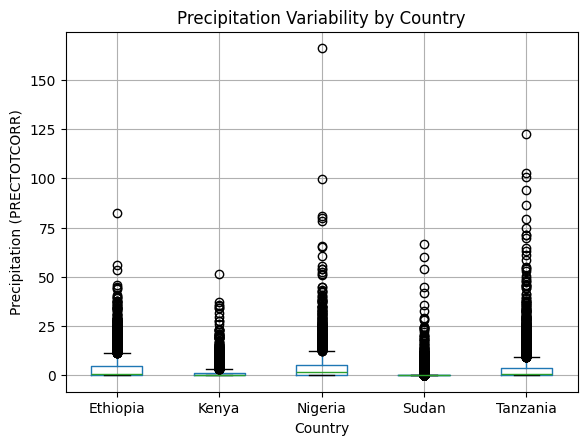

In [14]:
import matplotlib.pyplot as plt

plt.figure()

df.boxplot(column="PRECTOTCORR", by="Country")

plt.title("Precipitation Variability by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Precipitation (PRECTOTCORR)")

plt.show()

In [15]:
heat_extreme = df[df["T2M_MAX"] > 35].groupby("Country").size().reset_index(name="Extreme_Heat_Days")
heat_extreme

,Country,Extreme_Heat_Days
0,Sudan,2694


In [16]:
df_sorted = df.sort_values(["Country", "DATE"])
df_sorted["is_dry"] = df_sorted["PRECTOTCORR"] < 1
df_sorted["streak_id"] = (
    df_sorted["is_dry"] != df_sorted.groupby("Country")["is_dry"].shift()
).cumsum()
dry_streaks = df_sorted[df_sorted["is_dry"]].groupby(["Country", "streak_id"]).size()

dry_streaks = dry_streaks.reset_index(name="streak_length")
dry_streaks
max_dry_streak = dry_streaks.groupby("Country")["streak_length"].max().reset_index(name="Max_Dry_Streak")
max_dry_streak

,Country,Max_Dry_Streak
0,Ethiopia,99
1,Kenya,56
2,Nigeria,80
3,Sudan,259
4,Tanzania,60


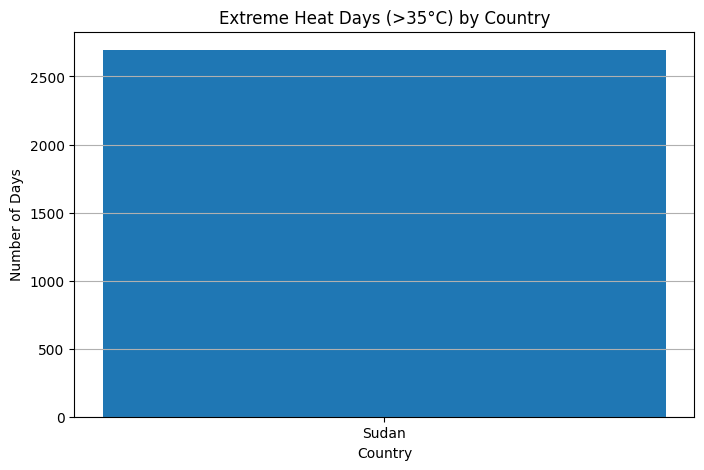

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(heat_extreme["Country"], heat_extreme["Extreme_Heat_Days"])

plt.title("Extreme Heat Days (>35°C) by Country")
plt.xlabel("Country")
plt.ylabel("Number of Days")
plt.grid(axis="y")

plt.show()

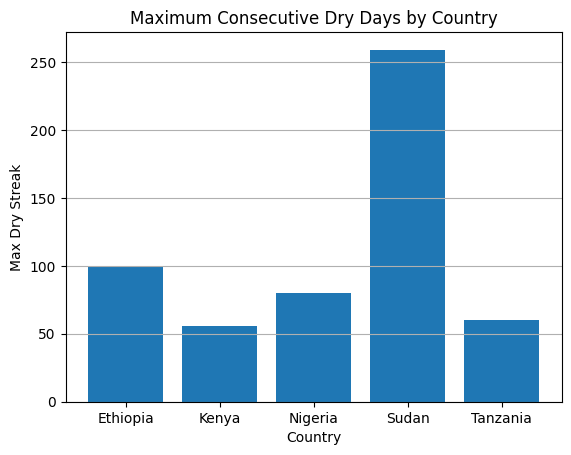

In [18]:
plt.figure()

plt.bar(max_dry_streak["Country"], max_dry_streak["Max_Dry_Streak"])

plt.title("Maximum Consecutive Dry Days by Country")
plt.xlabel("Country")
plt.ylabel("Max Dry Streak")
plt.grid(axis="y")

plt.show()

In [22]:
vulnerability = temp_summary.merge(precip_summary, on="Country", how="outer")
vulnerability = vulnerability.merge(heat_extreme, on="Country", how="outer")
vulnerability = vulnerability.merge(max_dry_streak, on="Country", how="outer")
vulnerability = vulnerability.fillna(0)
vulnerability

,Country,mean_x,median_x,std_x,mean_y,median_y,std_y,Extreme_Heat_Days,Max_Dry_Streak
0,Ethiopia,16.068500,16.04,1.898050,3.633795,0.82,6.289061,0.0,99
1,Kenya,20.427600,20.36,1.440824,1.468162,0.38,3.180228,0.0,56
2,Nigeria,26.656928,26.82,1.123335,4.213914,1.84,7.266742,0.0,80
3,Sudan,28.759007,29.16,4.681305,0.643875,0.00,3.057672,2694.0,259
4,Tanzania,26.802422,26.99,1.325388,3.740256,0.64,8.003947,0.0,60


In [24]:
vulnerability["score"] = (
    vulnerability["mean_x"] +
    vulnerability["std_x"] +
    vulnerability["std_y"] +
    vulnerability["Extreme_Heat_Days"] +
    vulnerability["Max_Dry_Streak"]
)

vulnerability = vulnerability.sort_values("score", ascending=False)
vulnerability

,Country,mean_x,median_x,std_x,mean_y,median_y,std_y,Extreme_Heat_Days,Max_Dry_Streak,score
3,Sudan,28.759007,29.16,4.681305,0.643875,0.00,3.057672,2694.0,259,2989.497984
0,Ethiopia,16.068500,16.04,1.898050,3.633795,0.82,6.289061,0.0,99,123.255612
2,Nigeria,26.656928,26.82,1.123335,4.213914,1.84,7.266742,0.0,80,115.047005
4,Tanzania,26.802422,26.99,1.325388,3.740256,0.64,8.003947,0.0,60,96.131758
1,Kenya,20.427600,20.36,1.440824,1.468162,0.38,3.180228,0.0,56,81.048652


### Climate Vulnerability Insights for COP32
- The country with the fastest warming trend is Sudan, indicating increasing long term heat stress and agricultural risk.
- The most unstable precipitation patterns are observed in Nigeria, showing high variability and risk of flooding and drought cycles.
- Extreme heat and drought frequency is highest in Sudan, suggesting strong exposure to climate stress and water insecurity.
- Ethiopia’s climate profile shows lower variability compared to its neighbors, with lower temperature variability and stable rainfall stability.
- Based on combined indicators, Sudan should be prioritized for climate finance support at COP32 due to consistently high vulnerability across temperature extremes and precipitation instability.